# Molecular GCMC: inserting and deleting whole molecules

mcpy can exchange rigid molecules (O$_2$, H$_2$O, CO, ...) with the reservoir:

* **Insertion** places a rigid template at a uniform random position with a uniform random 3D orientation (a fresh rotation for every trial).
* **Deletion** removes one complete molecule, chosen uniformly among those whose center of mass lies inside the sampling region.
* The acceptance criterion is the textbook rigid-molecule form: $N$ is the number of molecules of that species in the region, $\Lambda$ comes from the total molecular mass, and $\mu$ is the **full molecular chemical potential** (orientations are sampled uniformly, so the rotational partition function is absorbed into $\mu$; in practice $\mu = E_\mathrm{molecule} + \Delta\mu$).

Bookkeeping is one integer per atom, `atoms.arrays['molecule_id']`: `-1` means "free atom", any other value groups the member atoms of one molecule.
See `docs/gcmc_acceptance_convention.rst` for the conventions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import molecule

from mcpy.cell import Cell
from mcpy.ensembles.grand_canonical_ensemble import GrandCanonicalEnsemble
from mcpy.moves import (MoleculeInsertionMove, MoleculeDeletionMove,
                        InsertionMove, DeletionMove, MoveSelector)

## 1. What one insertion does

In [2]:
box = Atoms(cell=[10, 10, 10], pbc=True)
cell = Cell(box)
water = molecule('H2O')
ins = MoleculeInsertionMove(cell, water, 'H2O', seed=1)

for _ in range(3):
    ins.do_trial_move(box)

print('symbols:     ', box.get_chemical_symbols())
print('molecule_id: ', box.arrays['molecule_id'])
print('O-H distances of molecule 0:',
      np.round(box.get_distances(0, [1, 2]), 4), '(template geometry, rigid)')

symbols:      ['O', 'H', 'H', 'O', 'H', 'H', 'O', 'H', 'H']
molecule_id:  [0 0 0 1 1 1 2 2 2]
O-H distances of molecule 0: [0.9686 0.9686] (template geometry, rigid)


Each molecule gets a fresh id (0, 1, 2, ...).
Every insertion draws a fresh random **position** (uniform in the box) and a fresh random **orientation**.
Left: the insertion positions of 300 trials fill the cubic cell uniformly.
Right: their O→H bond *directions* (unit vectors, so they lie on the unit sphere by construction) are uniform over the sphere — no preferred orientation.

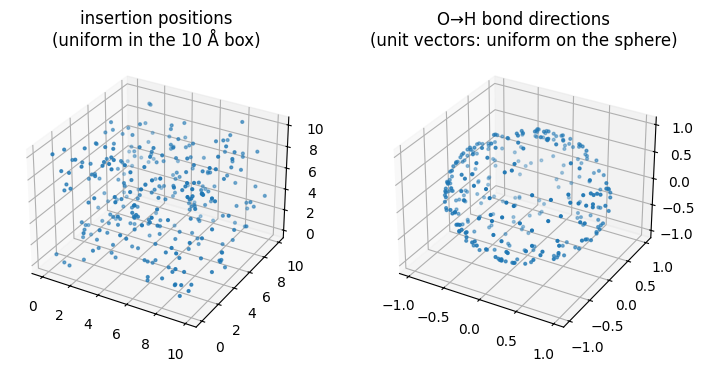

In [3]:
coms, vecs = [], []
for _ in range(300):
    b = Atoms(cell=[10, 10, 10], pbc=True)
    MoleculeInsertionMove(Cell(b), water, 'H2O',
                          seed=np.random.randint(1e6)).do_trial_move(b)
    coms.append(b.positions[0])                      # insertion position (O atom)
    v = b.positions[1] - b.positions[0]              # O->H bond vector
    vecs.append(v / np.linalg.norm(v))               # direction only (unit length)
coms, vecs = np.array(coms), np.array(vecs)

fig = plt.figure(figsize=(7.5, 3.6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(*coms.T, s=4)
ax1.set_title('insertion positions\n(uniform in the 10 Å box)')
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(*vecs.T, s=4)
ax2.set_title('O→H bond directions\n(unit vectors: uniform on the sphere)')
plt.tight_layout(); plt.show()

## 2. Deletion removes whole molecules, matched by composition

In [4]:
dele = MoleculeDeletionMove(cell, water, 'H2O', seed=2)
print('before:', box.get_chemical_formula(), '| ids:', box.arrays['molecule_id'])
dele.do_trial_move(box)
print('after: ', box.get_chemical_formula(), '| ids:', box.arrays['molecule_id'])

before: H6O3 | ids: [0 0 0 1 1 1 2 2 2]
after:  H4O2 | ids: [1 1 1 2 2 2]


## 3. A real (toy) simulation: LJ dimers

A short grand-canonical run of a rigid diatomic in LJ units, exchange-only.
This exact setup reproduces LAMMPS `fix gcmc mol` to better than 1.2 sigma (`benchmark/README.md`, stage 2).

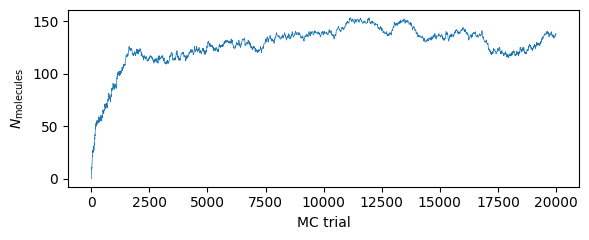

<N_mol> (last half) = 136.5


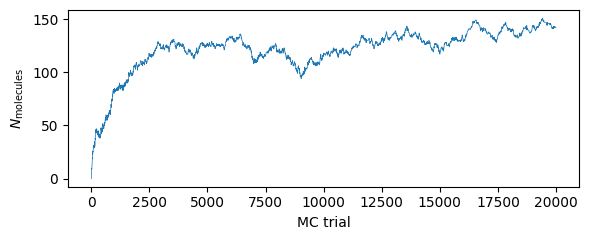

<N_mol> (last half) = 132.7


In [6]:
class LJCalc:
    RC = 3.0
    E_SHIFT = 4.0 * (RC**-12 - RC**-6)
    def __init__(self, box):
        self.box = box
    def get_potential_energy(self, atoms):
        pos = atoms.positions
        if len(pos) < 2:
            return 0.0
        d = pos[:, None, :] - pos[None, :, :]
        d -= self.box * np.round(d / self.box)
        r2 = np.einsum('ijk,ijk->ij', d, d)[np.triu_indices(len(pos), k=1)]
        r2 = r2[r2 < self.RC**2]
        inv6 = 1.0 / r2**3
        return float(np.sum(4.0 * (inv6*inv6 - inv6) - self.E_SHIFT))

L, T = 9.0, 2.0
dimer = Atoms('O2', positions=[[0, 0, 0], [0, 0, 1.0]])  # LJ(1.0) = 0 exactly
atoms = Atoms(cell=[L, L, L], pbc=True)
cell = Cell(atoms)
ms = MoveSelector([1, 1],
                  [MoleculeInsertionMove(cell, dimer, 'O2', seed=21, min_insert=0.8),
                   MoleculeDeletionMove(cell, dimer, 'O2', seed=22)],
                  seed=23, n_moves=1)
g = GrandCanonicalEnsemble(atoms=atoms, cells=[cell], units_type='LJ',
                           calculator=LJCalc(L), mu={'O2': -5.0}, species=[],
                           molecules={'O2': dimer},           # <- registers the species
                           temperature=T, move_selector=ms, random_seed=24,
                           traj_file=None, outfile=None)
trace = []
for _ in range(20_000):
    g.do_gcmc_step()
    trace.append(len(g.atoms) // 2)
plt.figure(figsize=(6, 2.5))
plt.plot(trace, lw=0.5)
plt.xlabel('MC trial'); plt.ylabel(r'$N_\mathrm{molecules}$')
plt.tight_layout(); plt.show()
print(f'<N_mol> (last half) = {np.mean(trace[10_000:]):.1f}')

## 4. The bookkeeping survives everything

Rollback on rejection, ASE `del atoms[...]`, and trajectory writing all preserve `molecule_id`; trajectories round-trip through `ase.io.read`.
Atomic and molecular species can coexist: atomic moves only ever touch *free* atoms (`molecule_id == -1`).

In [7]:
# atomic O co-existing with O2 molecules: the atomic deletion move
# only picks free atoms, never molecule members.
mixed = Atoms(cell=[10, 10, 10], pbc=True)
c2 = Cell(mixed)
MoleculeInsertionMove(c2, dimer, 'O2', seed=5).do_trial_move(mixed)
InsertionMove(c2, species=['O'], seed=6).do_trial_move(mixed)   # one free O
print('ids:', mixed.arrays['molecule_id'], '(-1 = free atom)')

for seed in range(5):
    probe = mixed.copy()
    DeletionMove(Cell(probe), species=['O'], seed=seed).do_trial_move(probe)
    assert (probe.arrays['molecule_id'] == 0).sum() == 2, 'molecule was harmed!'
print('atomic deletion removed the free O every time; the O2 is untouchable.')

ids: [ 0  0 -1] (-1 = free atom)
atomic deletion removed the free O every time; the O2 is untouchable.


**Caveats worth knowing** (details in `docs/gcmc_acceptance_convention.rst`):

* With a relaxing calculator the molecule's internal geometry is free after insertion; deletion still removes it as one unit (matched by composition).
* **Dissociation**: if relaxation splits a molecule (e.g. O$_2$ on a reactive metal), the atoms keep their shared `molecule_id` — the pair stays deletable as one unit, but that deletion is energetically near-impossible once the atoms bind the surface, so split pairs become effectively permanent. For dissociating species, run *both* channels — molecular moves plus atomic moves at $\mu_\mathrm{atom} = \mu_\mathrm{molecule}/2$ — and let the potential decide the speciation; count intact molecules by bond-length cutoff in analysis, not by id.
* Two molecular species with the same composition (isomers) cannot coexist.
* `min_insert` biases the sampled ensemble at high density (documented); the textbook criterion is exact for `min_insert=None`.
* Use `BatchedReplicaExchange` for replica exchange with molecules (the MPI `ReplicaExchange` refuses them).

Next: `co_on_cupd_replica_exchange.ipynb` for the production-style workflow with a MACE potential.